## Installing some required packages

In [ ]:
pip install mne

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 7.6 MB 6.8 MB/s 


In [ ]:
pip install fastbook

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 719 kB 3.8 MB/s 
     |████████████████████████████████| 451 kB 40.0 MB/s 
     |████████████████████████████████| 1.3 MB 51.3 MB/s 
     |████████████████████████████████| 5.5 MB 40.4 MB/s 
     |████████████████████████████████| 1.6 MB 65.7 MB/s 
     |████████████████████████████████| 182 kB 56.2 MB/s 
     |████████████████████████████████| 115 kB 51.2 MB/s 
     |████████████████████████████████| 212 kB 55.3 MB/s 
     |████████████████████████████████| 127 kB 46.5 MB/s 
     |████████████████████████████████| 7.6 MB 32.7 MB/s 
  Attempting uninstall: urllib3
    Found existing installation: urllib3 1.24.3
    Uninstalling urllib3-1.24.3:
      Successfully uninstalled urllib3-1.24.3


In [ ]:
from multiprocessing import Pool
import os
import numpy as np
import mne
import pandas as pd
import random

from tqdm import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.fftpack import fft, fftfreq, rfft, rfftfreq
from sklearn.preprocessing import quantile_transform
from sklearn.preprocessing import minmax_scale
from sklearn.preprocessing import normalize
from sklearn.preprocessing import scale
from sklearn.preprocessing import robust_scale

from fastbook import GetAttr
from fastbook import DataBlock
from fastbook import add_props
from fastbook import ImageBlock
from fastbook import CategoryBlock
from fastbook import get_image_files
from fastbook import RandomSplitter
from fastbook import parent_label
from fastbook import Resize
from fastbook import Path
from fastbook import cnn_learner
from fastbook import error_rate
from fastbook import resnet18
from fastbook import resnet50
from fastbook import ClassificationInterpretation
from fastbook import xresnet18

import matplotlib
from collections import defaultdict
from math import cos, sin, acos, radians, pi
from scipy.interpolate import griddata
from scipy.cluster.hierarchy import complete, single, average, ward, fcluster
from numpy import newaxis
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, utils

import pywt


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
train_dir = '/content/drive/My Drive/Colab Notebooks/FYP/Train/'
test_dir = '/content/drive/My Drive/Colab Notebooks/FYP/Test/'

def read_csv(filename):
    return pd.read_csv(filename)

files_train = os.listdir(train_dir)
file_list_train = [os.path.join(train_dir,filename) for filename in files_train if filename.split('.')[1]=='csv']

files_test = os.listdir(test_dir)
file_list_test = [os.path.join(test_dir,filename) for filename in files_test if filename.split('.')[1]=='csv']

with Pool(processes=12) as pool:

    df_list_train = pool.map(read_csv, file_list_train)
    df_list_test =  pool.map(read_csv, file_list_test)

combined_df_train = pd.concat(df_list_train, ignore_index=True)
combined_df_test = pd.concat(df_list_test, ignore_index=True)
combined_df = pd.concat([combined_df_train,combined_df_test], ignore_index=True)

EEG_data = combined_df[combined_df['subject identifier'] == 'a']
EEG_data_control = combined_df[combined_df['subject identifier'] == 'c']

del combined_df

In [ ]:
EEG_data

,Unnamed: 0,trial number,sensor position,sample num,sensor value,subject identifier,matching condition,channel,name,time
0,5,17,FP1,0,-3.153,a,S2 match,0,co2a0000369,0.000000
1,6,17,FP1,1,-3.153,a,S2 match,0,co2a0000369,0.003906
2,7,17,FP1,2,-3.642,a,S2 match,0,co2a0000369,0.007812
3,8,17,FP1,3,-4.130,a,S2 match,0,co2a0000369,0.011719
4,9,17,FP1,4,-4.618,a,S2 match,0,co2a0000369,0.015625
...,...,...,...,...,...,...,...,...,...,...
15712251,16447,77,Y,251,-13.438,a,S2 match,63,co2a0000368,0.980469
15712252,16448,77,Y,252,-13.926,a,S2 match,63,co2a0000368,0.984375
15712253,16449,77,Y,253,-15.879,a,S2 match,63,co2a0000368,0.988281
15712254,16450,77,Y,254,-17.344,a,S2 match,63,co2a0000368,0.992188


**Data Wrangling**

In [ ]:
EEG_data = EEG_data.drop(['Unnamed: 0'], axis=1)
EEG_data.loc[EEG_data['matching condition'] == 'S2 nomatch,', 'matching condition'] =  'S2 nomatch'
EEG_data.loc[EEG_data['sensor position'] == 'AF1', 'sensor position'] = 'AF3'
EEG_data.loc[EEG_data['sensor position'] == 'AF2', 'sensor position'] = 'AF4'
EEG_data.loc[EEG_data['sensor position'] == 'PO1', 'sensor position'] = 'PO3'
EEG_data.loc[EEG_data['sensor position'] == 'PO2', 'sensor position'] = 'PO4'

EEG_data.loc[EEG_data['sensor position'] == 'FP1', 'sensor position'] = 'Fp1'
EEG_data.loc[EEG_data['sensor position'] == 'FP2', 'sensor position'] = 'Fp2'
EEG_data.loc[EEG_data['sensor position'] == 'CPZ', 'sensor position'] = 'CPz'
EEG_data.loc[EEG_data['sensor position'] == 'FZ', 'sensor position'] = 'Fz'

EEG_data.loc[EEG_data['sensor position'] == 'CZ', 'sensor position'] = 'Cz'

EEG_data.loc[EEG_data['sensor position'] == 'PZ', 'sensor position'] = 'Pz'
EEG_data.loc[EEG_data['sensor position'] == 'FPZ', 'sensor position'] = 'Fpz'
EEG_data.loc[EEG_data['sensor position'] == 'AFZ', 'sensor position'] = 'AFz'
EEG_data.loc[EEG_data['sensor position'] == 'FCZ', 'sensor position'] = 'FCz'

EEG_data.loc[EEG_data['sensor position'] == 'POZ', 'sensor position'] = 'POz'
EEG_data.loc[EEG_data['sensor position'] == 'OZ', 'sensor position'] = 'Oz'

EEG_data_control = EEG_data_control.drop(['Unnamed: 0'], axis=1)
EEG_data_control.loc[EEG_data_control['matching condition'] == 'S2 nomatch,', 'matching condition'] =  'S2 nomatch'

EEG_data_control.loc[EEG_data_control['sensor position'] == 'AF1', 'sensor position'] = 'AF3'
EEG_data_control.loc[EEG_data_control['sensor position'] == 'AF2', 'sensor position'] = 'AF4'
EEG_data_control.loc[EEG_data_control['sensor position'] == 'PO1', 'sensor position'] = 'PO3'
EEG_data_control.loc[EEG_data_control['sensor position'] == 'PO2', 'sensor position'] = 'PO4'

EEG_data_control.loc[EEG_data_control['sensor position'] == 'FP1', 'sensor position'] = 'Fp1'
EEG_data_control.loc[EEG_data_control['sensor position'] == 'FP2', 'sensor position'] = 'Fp2'
EEG_data_control.loc[EEG_data_control['sensor position'] == 'CPZ', 'sensor position'] = 'CPz'
EEG_data_control.loc[EEG_data_control['sensor position'] == 'FZ', 'sensor position'] = 'Fz'

EEG_data_control.loc[EEG_data_control['sensor position'] == 'CZ', 'sensor position'] = 'Cz'

EEG_data_control.loc[EEG_data_control['sensor position'] == 'PZ', 'sensor position'] = 'Pz'
EEG_data_control.loc[EEG_data_control['sensor position'] == 'FPZ', 'sensor position'] = 'Fpz'
EEG_data_control.loc[EEG_data_control['sensor position'] == 'AFZ', 'sensor position'] = 'AFz'
EEG_data_control.loc[EEG_data_control['sensor position'] == 'FCZ', 'sensor position'] = 'FCz'

EEG_data_control.loc[EEG_data_control['sensor position'] == 'POZ', 'sensor position'] = 'POz'
EEG_data_control.loc[EEG_data_control['sensor position'] == 'OZ', 'sensor position'] = 'Oz'


In [ ]:
Alc_S1Obj = EEG_data[EEG_data['matching condition'] == 'S1 obj']
Alc_S2Match = EEG_data[EEG_data['matching condition'] == 'S2 match']
Alc_S2Nomatch = EEG_data[EEG_data['matching condition'] == 'S2 nomatch']

Con_S1Obj = EEG_data_control[EEG_data_control['matching condition'] == 'S1 obj']
Con_S2Match = EEG_data_control[EEG_data_control['matching condition'] == 'S2 match']
Con_S2Nomatch = EEG_data_control[EEG_data_control['matching condition'] == 'S2 nomatch']


def trial_len_integrity_check(inputDF):

  nameAndTrialNumber = inputDF.groupby(['trial number','name']).size().reset_index().rename(columns={0:'count'})
  nameAndTrialNumber['count'] =np.where(nameAndTrialNumber['count'] == 16384,False,True)

  del inputDF

  if nameAndTrialNumber['count'].any():
    Exception('Data Integrity problem, one of the arrays is not shaped 256x256')

  return nameAndTrialNumber[['trial number','name']]

Con_S1Obj_Index = trial_len_integrity_check(Con_S1Obj)
Con_S2Match_Index = trial_len_integrity_check(Con_S2Match)
Con_S2Nomatch_Index = trial_len_integrity_check(Con_S2Nomatch)

Alc_S1Obj_Index = trial_len_integrity_check(Alc_S1Obj)
Alc_S2Match_Index = trial_len_integrity_check(Alc_S2Match)
Alc_S2Nomatch_Index = trial_len_integrity_check(Alc_S2Nomatch)

All_Alcs = pd.concat([Alc_S1Obj_Index,Alc_S2Match_Index,Alc_S2Nomatch_Index])
All_Cons = pd.concat([Con_S1Obj_Index,Con_S2Match_Index,Con_S2Nomatch_Index])

All_Alcs.reset_index(drop=True,inplace=True)
All_Cons.reset_index(drop=True,inplace=True)

## Clustering of the channels

In [ ]:
def cluster_channels(distance_matrix,num_of_clusters):

  def hierarchical_clustering(dist_mat, method='ward'):
    if method == 'complete':
        Z = complete(distance_matrix)
    if method == 'single':
        Z = single(distance_matrix)
    if method == 'average':
        Z = average(distance_matrix)
    if method == 'ward':
        Z = ward(distance_matrix)



    return Z

  linkage_matrix = hierarchical_clustering(distance_matrix)



  cluster_labels = fcluster(linkage_matrix, num_of_clusters, criterion='maxclust')
  return cluster_labels

def select_clusters(cluster_index,totalFramesToInclude):

    unique_clusters = np.unique(cluster_index)
    unique_clusters_count = np.unique(cluster_index,return_counts=True)[1]

    unique_clusters_count[unique_clusters_count != 0]


    unique , count = np.unique(cluster_index, return_counts=True)

    count_sort_ind = np.argsort(-count)

    size_sorted_clusters = unique[count_sort_ind]



    largerClusters = [k for k,v in enumerate(size_sorted_clusters) if v > 1]



    largerClusters = [x for x in largerClusters if not x == 0]

    largerClusters = sorted(largerClusters)




    if len(largerClusters) == totalFramesToInclude:

      final_clusters = largerClusters


    elif len(largerClusters) > totalFramesToInclude:

      largerClusters = sorted(largerClusters)

      x = totalFramesToInclude
      largerClusters = largerClusters[0:x]


    elif len(largerClusters) < totalFramesToInclude:

      sizeOneClusters = list(set(unique_clusters).difference(largerClusters))


      numToRandSelect = totalFramesToInclude - len(largerClusters)
      random_small_clusters = random.sample(sizeOneClusters,numToRandSelect)
      largerClusters = largerClusters + random_small_clusters

    else:
      Exception('size error')

    if not len(largerClusters) == totalFramesToInclude:
      print('not ok')



    final_clusters = np.array(largerClusters)

    return final_clusters




def select_channels_to_transform(trial_index, clusters_index, final_clusters_index):


  finalChannelsIndex = {}


  for i in np.nditer(final_clusters_index):
    timeSeriesIndices = np.where(clusters_index==i)[0]
    if timeSeriesIndices.shape[0] == 0:
      print(len(timeSeriesIndices))

    randomSelectionIndex = np.random.choice(timeSeriesIndices)
    finalChannelsIndex[randomSelectionIndex] = i

  return finalChannelsIndex

In [ ]:
def pull_one_second_frame(row, trial_index,input_data):

    return input_data[(input_data['trial number'] == trial_index.loc[row]['trial number']) &
             (input_data['name'] == trial_index.loc[row]['name'])].pivot_table(index='channel', columns='time', values = 'sensor value')

## Data Processing using Wavelet Transform

In [ ]:
def wavelet_transformation_plot_to_array(signal):
    dt = 0.8
    time = np.arange(0,256,1)
    scales = np.arange(1, 256)




    def plot_wavelet(ax, time, signal, scales, waveletname = 'morl',
                    cmap = plt.cm.seismic, title = '', ylabel = '', xlabel = ''):

        dt = time[1] - time[0]
        [coefficients, frequencies] = pywt.cwt(signal, scales, waveletname, dt)
        power = (abs(coefficients)) ** 2
        period = 1. / frequencies


        levels = [0.1,4.3,7.3,21.3,32,64,512]

        contourlevels = np.log2(levels)

        im = ax.contourf(time, np.log2(period), np.log2(power), contourlevels, extend='both',cmap=cmap)


        plt.ioff()




        yticks = 2**np.arange(np.ceil(np.log2(period.min())), np.ceil(np.log2(period.max())))
        ax.set_yticks(np.log2(yticks))
        ax.set_yticklabels(yticks)

        ax.invert_yaxis()
        ylim = ax.get_ylim()
        ax.set_ylim(ylim[0], -1)
        return yticks, ylim

    x = signal
    title = ''
    ylabel = ''
    xlabel = ''



    fig, ax = plt.subplots(figsize=(4,4))
    plt.ioff()
    plot_wavelet(ax, time, signal, scales, xlabel=xlabel, ylabel=ylabel, title=title)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.margins(x=0,y=0)
    plt.tight_layout(pad=0, rect=(0,0,0,0))



    def fig2data ( fig ):
        fig.canvas.draw ( )

        w,h = fig.canvas.get_width_height()
        buf = np.frombuffer ( fig.canvas.tostring_argb(), dtype=np.uint8 )
        buf.shape = ( w, h,4 )


        buf = np.roll ( buf, 3, axis = 2 )
        return buf
    plt.close()
    outputArray = fig2data(fig)

    return outputArray

In [ ]:
def rgba2rgb( rgba, background=(255,255,255) ):
    row, col, ch = rgba.shape

    if ch == 3:
        return rgba

    assert ch == 4, 'RGBA image has 4 channels.'

    rgb = np.zeros( (row, col, 3), dtype='float32' )
    r, g, b, a = rgba[:,:,0], rgba[:,:,1], rgba[:,:,2], rgba[:,:,3]

    a = np.asarray( a, dtype='float32' ) / 255.0

    R, G, B = background

    rgb[:,:,0] = r * a + (1.0 - a) * R
    rgb[:,:,1] = g * a + (1.0 - a) * G
    rgb[:,:,2] = b * a + (1.0 - a) * B

    return np.asarray( rgb, dtype='uint8' )

In [ ]:
def name_image_a_or_c(trial, trial_index):

  trial_num = str(trial_index.loc[trial]['trial number'])
  subject_ID = str(trial_index.loc[trial]['name'])
  experiment_condition = str(trial_index.loc[trial]['trial info'])

  fileName = experiment_condition + '_' + trial_num + '_' + subject_ID + '.jpg'

  return fileName


In [ ]:
!mkdir /home/FYP
!mkdir /home/FYP/EEG

fastAI_root_dir = '/home/FYP/EEG'


!mkdir /home/FYP/EEG/Con
!mkdir /home/FYP/EEG/Alc
Alc_Dir = '/home/FYP/EEG/Alc'
Con_Dir = '/home/FYP/EEG/Con'

!mkdir /home/FYP/EEG_Groups

orig_root_dir = '/home/FYP/EEG_Groups'



!mkdir /home/FYP/EEG_Groups/alc_s1Obj
!mkdir /home/FYP/EEG_Groups/alc_s2Match
!mkdir /home/FYP/EEG_Groups/alc_s2Nomatch

Alc_S1Obj_Dir = '/home/FYP/EEG_Groups/alc_s1Obj'
Alc_S2Match_Dir = '/home/FYP/EEG_Groups/alc_s2Match'
Alc_S2Nomatch_Dir = '/home/FYP/EEG_Groups/alc_s2Nomatch'



!mkdir /home/FYP/EEG_Groups/con_s1Obj
!mkdir /home/FYP/EEG_Groups/con_s2Match
!mkdir /home/FYP/EEG_Groups/con_s2Nomatch

Con_S1Obj_Dir = '/home/FYP/EEG_Groups/con_s1Obj'
Con_S2Match_Dir = '/home/FYP/EEG_Groups/con_s2Match'
Con_S2Nomatch_Dir = '/home/FYP/EEG_Groups/con_s2Nomatch'

In [ ]:
Alc_S1Obj_Index['trial info'] = 'a_S1Obj'
Alc_S2Match_Index['trial info'] = 'a_S2Match'
Alc_S2Nomatch_Index['trial info'] = 'a_S2Nomatch'

Con_S1Obj_Index['trial info'] = 'c_S1Obj'
Con_S2Match_Index['trial info'] = 'c_S2Match'
Con_S2Nomatch_Index['trial info'] = 'c_S2Nomatch'


All_Alcs = pd.concat([Alc_S1Obj_Index,Alc_S2Match_Index,Alc_S2Nomatch_Index])
All_Cons = pd.concat([Con_S1Obj_Index,Con_S2Match_Index,Con_S2Nomatch_Index])

All_Alcs.reset_index(drop=True,inplace=True)
All_Cons.reset_index(drop=True,inplace=True)

### Continuous Wavelet Transform For Alcoholic group

In [ ]:
import cv2


input_data = EEG_data
trial_index = All_Alcs

img_directory = Alc_Dir


num_of_clusters = 14
totalFramesToInclude = 9



for trial in trial_index.index:
  EEG_Frame = pull_one_second_frame(trial,trial_index,input_data)


  cluster_labels = cluster_channels(EEG_Frame,num_of_clusters)

  final_clusters = select_clusters(cluster_labels,totalFramesToInclude)


  final_channels = select_channels_to_transform(trial_index,cluster_labels,final_clusters)


  array_dict = {}

  for key in final_channels.keys():

    signal = EEG_Frame.loc[key]


    np_array = wavelet_transformation_plot_to_array(signal)
    plt.close()
    np_array = rgba2rgb(np_array)



    array_dict[key] = np_array




  ordered_keys = list(array_dict.keys())

  for (k,v) in array_dict.items():
    array_dict[k] = cv2.resize(v,(200,200))


  horizontalRow1 = np.hstack([array_dict[ordered_keys[0]],array_dict[ordered_keys[1]],array_dict[ordered_keys[2]]])
  horizontalRow2 = np.hstack([array_dict[ordered_keys[3]],array_dict[ordered_keys[4]],array_dict[ordered_keys[5]]])
  horizontalRow3 = np.hstack([array_dict[ordered_keys[6]],array_dict[ordered_keys[7]],array_dict[ordered_keys[8]]])


  collaged_array = np.vstack([horizontalRow1,horizontalRow2,horizontalRow3])

  nameOfCollage = name_image_a_or_c(int(trial),trial_index)



  filePath = os.path.join(img_directory,nameOfCollage)
  cv2.imwrite(filePath,collaged_array)

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:29: RuntimeWarning: divide by zero encountered in log2
/usr/local/lib/python3.7/dist-packages/matplotlib/contour.py:1483: UserWarning: Warning: converting a masked element to nan.
  self.zmax = float(z.max())
/usr/local/lib/python3.7/dist-packages/matplotlib/contour.py:1484: UserWarning: Warning: converting a masked element to nan.
  self.zmin = float(z.min())


### Continuous Wavelet Transform For Control group

In [ ]:
input_data = EEG_data_control
trial_index = All_Cons

img_directory = Con_Dir


num_of_clusters = 14
totalFramesToInclude = 9



for trial in trial_index.index:
  EEG_Frame = pull_one_second_frame(trial,trial_index,input_data)


  cluster_labels = cluster_channels(EEG_Frame,num_of_clusters)

  final_clusters = select_clusters(cluster_labels,totalFramesToInclude)



  final_channels = select_channels_to_transform(trial_index,cluster_labels,final_clusters)


  array_dict = {}

  for key in final_channels.keys():
    signal = EEG_Frame.loc[key]



    np_array = wavelet_transformation_plot_to_array(signal)
    np_array = rgba2rgb(np_array)



    array_dict[key] = np_array




  ordered_keys = list(array_dict.keys())

  for (k,v) in array_dict.items():
    array_dict[k] = cv2.resize(v,(200,200))


  horizontalRow1 = np.hstack([array_dict[ordered_keys[0]],array_dict[ordered_keys[1]],array_dict[ordered_keys[2]]])
  horizontalRow2 = np.hstack([array_dict[ordered_keys[3]],array_dict[ordered_keys[4]],array_dict[ordered_keys[5]]])
  horizontalRow3 = np.hstack([array_dict[ordered_keys[6]],array_dict[ordered_keys[7]],array_dict[ordered_keys[8]]])


  collaged_array = np.vstack([horizontalRow1,horizontalRow2,horizontalRow3])

  nameOfCollage = name_image_a_or_c(int(trial),trial_index)



  filePath = os.path.join(img_directory,nameOfCollage)
  cv2.imwrite(filePath,collaged_array)




/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:29: RuntimeWarning: divide by zero encountered in log2


In [ ]:
Alc_Dir = '/home/FYP/EEG/Alc'
Con_Dir = '/home/FYP/EEG/Con'


EEG_Con_Path = Con_Dir
EEG_Alc_Path = Alc_Dir

List_EEG_Con = [os.path.join(EEG_Con_Path, f) for f in os.listdir(EEG_Con_Path)]
List_EEG_Alc = [os.path.join(EEG_Alc_Path, f) for f in os.listdir(EEG_Alc_Path)]

root_dir = '/home/FYP/EEG'

In [ ]:
NumOfControlImages = len(List_EEG_Con)
NumOfAlchImages = len(List_EEG_Alc)

print(f'Control Group size {NumOfControlImages}')
print(f'Alcholic Group size: {NumOfAlchImages}')

Control Group size 456
Alcholic Group size: 468


## Part 1: Implementation of CNN

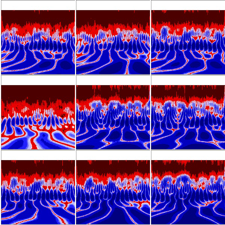

In [ ]:
from PIL import Image
picked_image = 77
im = Image.open(List_EEG_Alc[picked_image])
im.to_thumb(225,225)

In [ ]:
class DataLoaders(GetAttr):
  def __init__(self, *loaders): self.loaders = loaders
  def __getitem__(self, i): return self.loaders[i]
  train,valid = add_props(lambda i, self: self[i])

In [ ]:
EEGs = DataBlock (
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter = RandomSplitter(valid_pct=0.2, seed=99),
    get_y=parent_label,
    item_tfms=Resize(225,225)
    )

In [ ]:
dls = EEGs.dataloaders(root_dir)

In [ ]:
learn = cnn_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(6)

/usr/local/lib/python3.7/dist-packages/fastai/vision/learner.py:288: UserWarning: `cnn_learner` has been renamed to `vision_learner` -- please update your code
  warn("`cnn_learner` has been renamed to `vision_learner` -- please update your code")
/usr/local/lib/python3.7/dist-packages/torchvision/models/_utils.py:209: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and will be removed in 0.15, please use 'weights' instead.
  f"The parameter '{pretrained_param}' is deprecated since 0.13 and will be removed in 0.15, "
/usr/local/lib/python3.7/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and will be removed in 0.15. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f370

  0%|          | 0.00/44.7M [00:00<?, ?B/s]

epoch,train_loss,valid_loss,error_rate,time
0,1.199683,1.039979,0.413043,02:55


epoch,train_loss,valid_loss,error_rate,time
0,0.745125,0.588465,0.304348,04:04
1,0.548295,0.533651,0.266304,03:57
2,0.387118,0.500430,0.206522,03:52
3,0.292509,0.473873,0.190217,03:53
4,0.219283,0.525057,0.228261,03:58
5,0.167095,0.529500,0.233696,03:51


## Part 2: Implementation of CNN + SVM Model

### Feature Extraction using CNN

In [ ]:
import time
start = time.time()

import numpy as np
from keras.applications.resnet import ResNet50, preprocess_input
from keras.utils import load_img, img_to_array
from keras.models import Model

base_model = ResNet50(weights='imagenet')
model = Model(inputs=base_model.input, outputs=base_model.get_layer('avg_pool').output)

image_size = 224
img_paths = List_EEG_Con + List_EEG_Alc
features_array = np.zeros((924,2048))

for i, img_path in enumerate(img_paths):
    img = load_img(img_path, target_size=(image_size, image_size))
    x = img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)
    features = model.predict(x)
    features = features.reshape(2048,)
    features_array[i,:] = features

print('Running time: %.4f seconds' % (time.time()-start))

1/1 [==============================] - 0s 216ms/step
Running time: 327.1078 seconds


In [ ]:
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 230, 230, 3)  0           ['input_2[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 112, 112, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                                                                                            

In [ ]:
features_array.shape

(924, 2048)

In [ ]:
label = [0]*456 + [1]*468

In [ ]:
df = pd.DataFrame(features_array)

In [ ]:
from sklearn.model_selection import train_test_split
X = df
y = label
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.1, random_state=68)

### Classification using SVM without cross validation

In [ ]:
import time
start = time.time()

from sklearn.svm import SVC
clf = SVC()
clf.fit(Xtrain, ytrain)
preds = clf.predict(Xtest)

print('Running time: %.4f seconds' % (time.time()-start))

Running time: 0.7305 seconds


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print(accuracy_score(ytest, preds))

0.8602150537634409


Text(0.5, 1.0, 'Confusion Matrix')

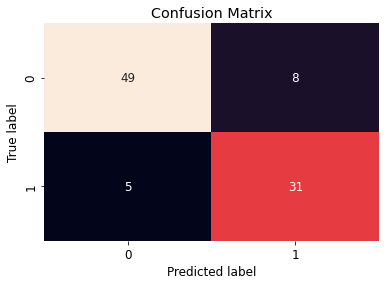

In [ ]:
cm = confusion_matrix(ytest, preds)
sns.heatmap(cm, annot=True, cbar=False)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix')

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(ytest, preds))

              precision    recall  f1-score   support

           0       0.91      0.86      0.88        57
           1       0.79      0.86      0.83        36

    accuracy                           0.86        93
   macro avg       0.85      0.86      0.85        93
weighted avg       0.86      0.86      0.86        93



### Classification using SVM with cross validation

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
import time
start = time.time()

from sklearn.metrics import make_scorer
scoring = {'AUC': 'roc_auc', 'Accuracy': make_scorer(accuracy_score)}

clf_cv = GridSearchCV(SVC(), cv=5, param_grid={'C':[1,10,100,1000], 'gamma':[0.0001,0.001,0.01,0.1,1]}, verbose=1,
                      scoring=scoring, refit='AUC', return_train_score=True)
clf_cv.fit(Xtrain, ytrain)

print('Running time: %.4f seconds' % (time.time()-start))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Running time: 231.1881 seconds


In [ ]:
best_clf_cv = clf_cv.best_estimator_
best_clf_cv

SVC(C=10, gamma=0.001)

In [ ]:
clf_cv.best_score_

0.8512940804766883

In [ ]:
preds_cv = best_clf_cv.predict(Xtest)
print(accuracy_score(ytest, preds_cv))

0.7956989247311828


Text(0.5, 1.0, 'Confusion Matrix')

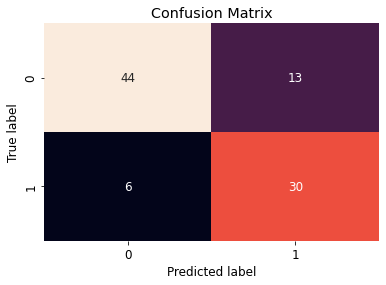

In [ ]:
cm = confusion_matrix(ytest, preds_cv)
sns.heatmap(cm, annot=True, cbar=False)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix')

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(ytest, preds_cv))

              precision    recall  f1-score   support

           0       0.88      0.77      0.82        57
           1       0.70      0.83      0.76        36

    accuracy                           0.80        93
   macro avg       0.79      0.80      0.79        93
weighted avg       0.81      0.80      0.80        93

